In [110]:
from dataclasses import dataclass
from enum import Enum, auto
from collections import Counter
import random

# -----------------------------
# 1. 定义花色与点数
# -----------------------------
class Suit(Enum):
    CLUB = 1
    DIAMOND = 2
    HEART = 3
    SPADE = 4

RANKS = ["2", "3", "4", "5", "6", "7", "8", "9", "10", "J", "Q", "K", "A"]
HCP_VALUE = {"J": 1, "Q": 2, "K": 3, "A": 4}


# -----------------------------
# 2. 定义 Card 类
# -----------------------------
@dataclass(frozen=True)
class Card:
    suit: Suit
    rank: str

    @property
    def hcp(self):
        return HCP_VALUE.get(self.rank, 0)

    def __str__(self):
        suit_symbol = {
            Suit.CLUB: "♣",
            Suit.DIAMOND: "♦",
            Suit.HEART: "♥",
            Suit.SPADE: "♠"
        }[self.suit]
        return f"{self.rank}{suit_symbol}"


# -----------------------------
# 3. 定义 Deck（牌堆）
# -----------------------------
class Deck:
    def __init__(self):
        self.cards = [
            Card(suit, rank)
            for suit in Suit
            for rank in RANKS
        ]

    def shuffle(self):
        random.shuffle(self.cards)

    def deal(self, n):
        """发 n 张牌"""
        hand_cards = self.cards[:n]
        self.cards = self.cards[n:]
        return hand_cards


# -----------------------------
# 4. 定义 Hand（玩家手牌）
# -----------------------------
class Hand:
    def __init__(self, cards):
        self.cards = cards

    @property
    def hcp(self):
        return sum(card.hcp for card in self.cards)

    def by_suit(self):
        """按花色分类"""
        suits = {suit: [] for suit in Suit}
        for card in self.cards:
            suits[card.suit].append(card)
        return suits

    @property
    def suit_lengths(self):
        """每个花色的张数统计（始终包含四个花色）"""
        suits = self.by_suit()
        return {suit: len(cards) for suit, cards in suits.items()}

    @property
    def distribution_points(self):
        """长套分：每超过4张的套加1分"""
        dp = 0
        for suit, length in self.suit_lengths.items():
            if length > 4:
                dp += (length - 4)
        return dp

    @property
    def shortage_points(self):
        """短套分：双缺3分，单张2分，双张1分"""
        sp = 0
        for suit, length in self.suit_lengths.items():
            if length == 0:
                sp += 3
            elif length == 1:
                sp += 2
            elif length == 2:
                sp += 1
        return sp

    @property
    def total_points(self):
        """总点数：HCP + 长套分（标准评估）"""
        return self.hcp + self.distribution_points

    def __str__(self):
        suits = self.by_suit()
        lines = []
        for suit in Suit:
            suit_cards = " ".join(str(c) for c in suits[suit])
            lines.append(f"{suit.name:<7}: {suit_cards}")
        lines.append(f"HCP     : {self.hcp}")
        lines.append(f"DistPts : {self.distribution_points}")
        lines.append(f"Total   : {self.total_points}")
        return "\n".join(lines)


# -----------------------------
# 5. 定义 Dealer（发牌器）
# -----------------------------
class Dealer:
    def __init__(self):
        self.deck = Deck()
        self.deck.shuffle()

    def deal_four(self):
        """发四家，每家 13 张"""
        return {
            "N": Hand(self.deck.deal(13)),
            "E": Hand(self.deck.deal(13)),
            "S": Hand(self.deck.deal(13)),
            "W": Hand(self.deck.deal(13)),
        }


In [111]:
# -----------------------------
# 6. 使用示例
# -----------------------------
dealer = Dealer()
hands = dealer.deal_four()

for seat, hand in hands.items():
    print(f"\n=== {seat} ===")
    print(hand)


=== N ===
CLUB   : 7♣ J♣ 9♣ 8♣ 3♣
DIAMOND: 9♦ A♦ 8♦ 5♦
HEART  : 8♥
SPADE  : 9♠ A♠ K♠
HCP     : 12
DistPts : 1
Total   : 13

=== E ===
CLUB   : 2♣ Q♣ 6♣ 5♣
DIAMOND: K♦ J♦
HEART  : K♥ 5♥ 7♥ A♥ 9♥
SPADE  : 5♠ 10♠
HCP     : 13
DistPts : 1
Total   : 14

=== S ===
CLUB   : A♣ K♣
DIAMOND: 2♦ Q♦ 10♦ 4♦
HEART  : 6♥ J♥ Q♥ 10♥
SPADE  : J♠ 7♠ Q♠
HCP     : 15
DistPts : 0
Total   : 15

=== W ===
CLUB   : 4♣ 10♣
DIAMOND: 7♦ 3♦ 6♦
HEART  : 4♥ 2♥ 3♥
SPADE  : 6♠ 2♠ 8♠ 3♠ 4♠
HCP     : 0
DistPts : 1
Total   : 1


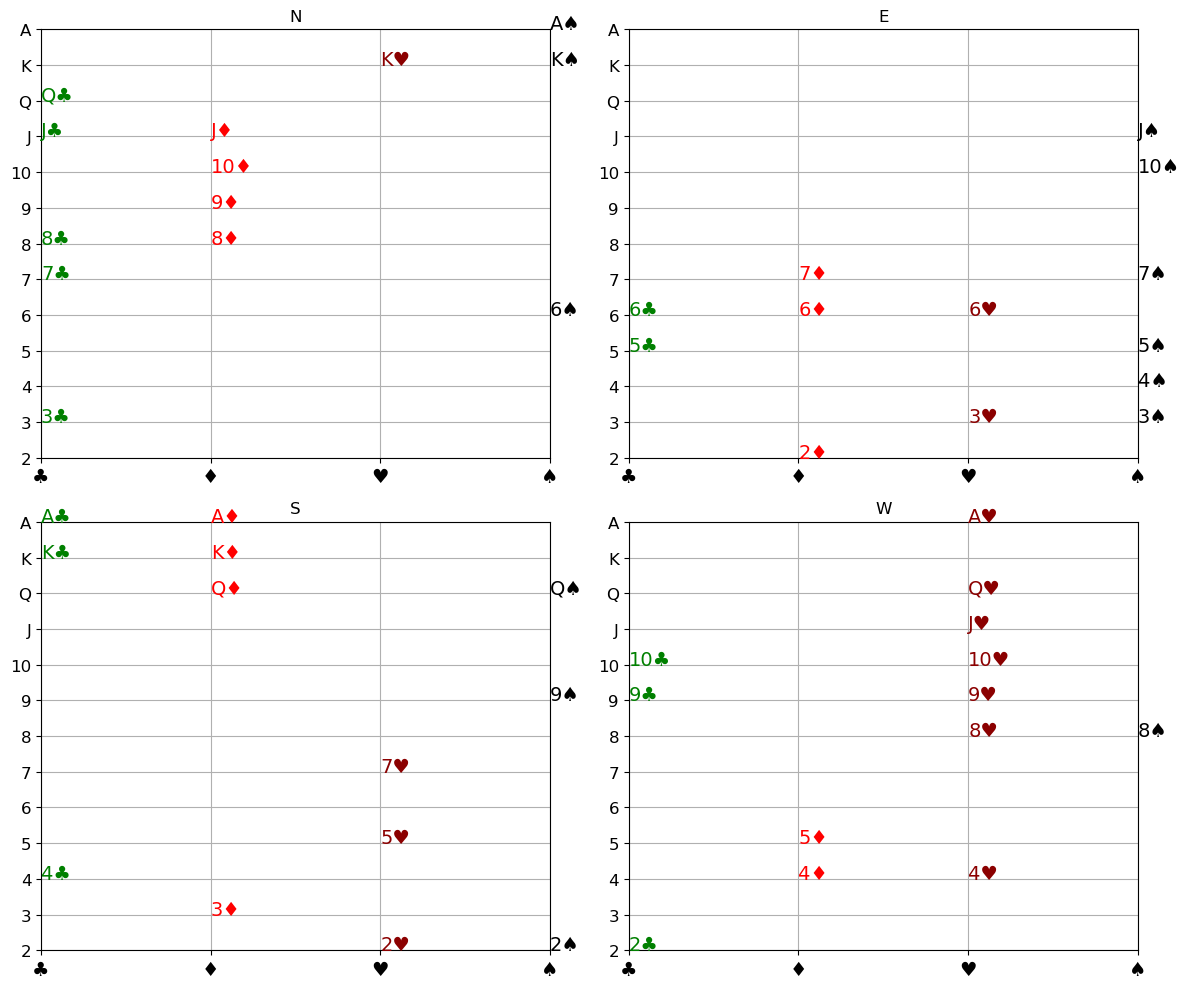

In [10]:
import matplotlib.pyplot as plt

# 花色映射成坐标
suit_to_x = {
    "CLUB": 0,
    "DIAMOND": 1,
    "HEART": 2,
    "SPADE": 3
}

rank_order = ["2","3","4","5","6","7","8","9","10","J","Q","K","A"]
rank_to_y = {rank: i for i, rank in enumerate(rank_order)}

suit_color = {
    "CLUB": "green",
    "DIAMOND": "red",
    "HEART": "darkred",
    "SPADE": "black"
}

def hand_to_plot_data(seat, hand):
    suits = hand.by_suit()
    data = []
    for suit, cards in suits.items():
        for c in cards:
            data.append({
                "seat": seat,
                "suit": suit.name,
                "rank": c.rank,
                "card": str(c),
                "x": suit_to_x[suit.name],
                "y": rank_to_y[c.rank]
            })
    return data

# 收集所有牌
plot_data = []
for seat, hand in hands.items():
    plot_data.extend(hand_to_plot_data(seat, hand))

import pandas as pd
df = pd.DataFrame(plot_data)

# 绘图
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, seat in zip(axes, df["seat"].unique()):
    sub = df[df["seat"] == seat]
    for _, row in sub.iterrows():
        ax.text(row["x"], row["y"], row["card"],
                color=suit_color[row["suit"]], fontsize=14)
    ax.set_title(seat)
    ax.set_xticks([0,1,2,3])
    ax.set_xticklabels(["♣","♦","♥","♠"], fontsize=14)
    ax.set_yticks(range(len(rank_order)))
    ax.set_yticklabels(rank_order, fontsize=12)
    ax.grid(True)

plt.tight_layout()
plt.show()